# Generación de señal de test
$$w_{1} =2*pi*f_{1}$$
$$f_{1}=2 \space hz$$
$$y(t) = sin(w_{1}*t)$$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

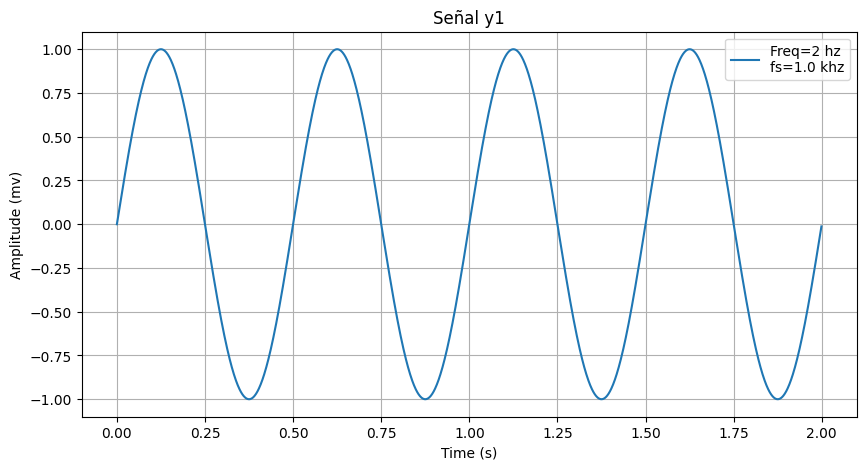

In [ ]:
f1 = 2 # hz
t1 = 1/f1  # seg
w1 = 2*np.pi*f1
fs = 1e3 # 1khz
ts = 1/fs

N_t1 = t1/ts
N = 4*N_t1
n = np.arange(N)
t = n*ts

y1 = np.sin(w1*t)

plt.figure(figsize=(10,5))
plt.title("Señal y1")
plt.plot(t,y1, label = f"Freq={f1} hz\nfs={fs*1e-3} khz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mv)")
plt.legend()
plt.grid()
plt.show()

$$y2 = 0.2sin(2pi*50*t) $$

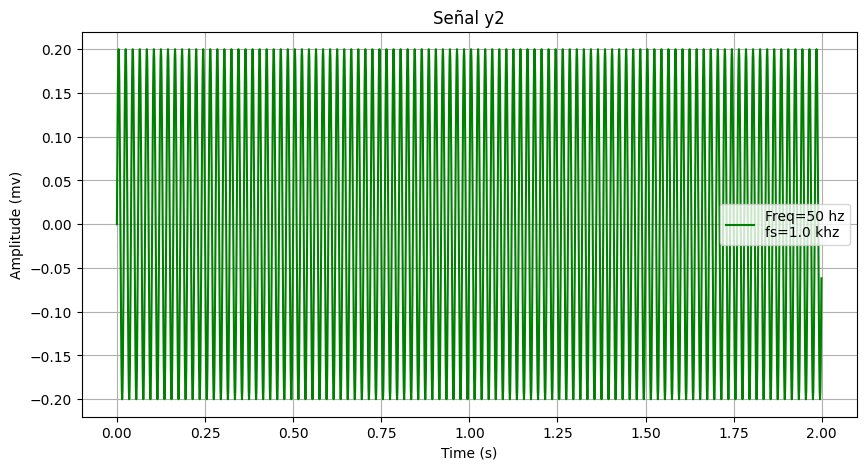

In [ ]:
f2 = 50

y2 = 0.2*np.sin(2*np.pi*f2*t)

plt.figure(figsize=(10,5))
plt.title("Señal y2")
plt.plot(t,y2, c='g',label = f"Freq={f2} hz\nfs={fs*1e-3} khz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mv)")
plt.legend()
plt.grid()
plt.show()

$$y = y1 + y2$$

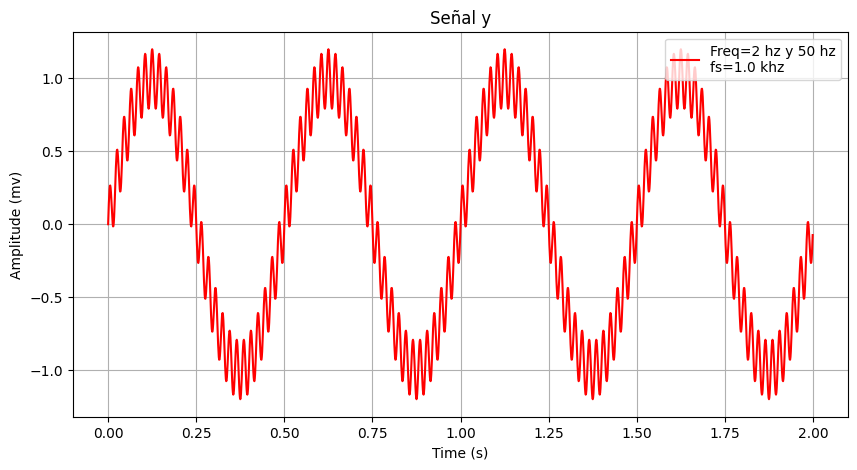

In [ ]:
y = y1 + y2

plt.figure(figsize=(10,5))
plt.title("Señal y")
plt.plot(t,y, c='red', label = f"Freq={f1} hz y {f2} hz\nfs={fs*1e-3} khz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mv)")
plt.legend(loc = "upper right")
plt.grid()
plt.show()

Valores originales de y: min=-1.2000, max=1.2000
Factor de escala aplicado: 106.2500
Offset aplicado: 127.5000
Valores escalados para DAC (0-255): min=0, max=255


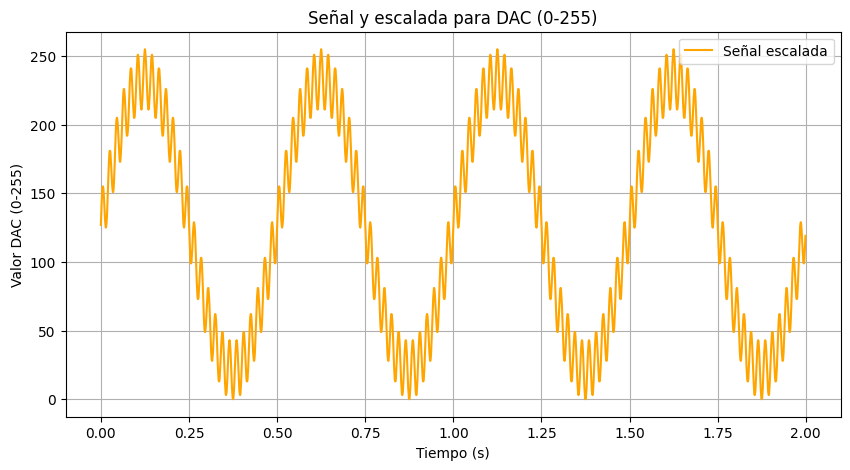

In [ ]:
# Escalar la señal 'y' al rango de 0-255 para un DAC de 8 bits

min_y = np.min(y)
max_y = np.max(y)

# Calculamos el factor de escala y el offset
# La fórmula para escalar un valor 'val' de un rango [min_orig, max_orig] a [min_dest, max_dest] es:
# scaled_val = (val - min_orig) * (max_dest - min_dest) / (max_orig - min_orig) + min_dest
# En nuestro caso: min_dest = 0, max_dest = 255

scale_factor = (255 - 0) / (max_y - min_y)
offset = 0 - min_y * scale_factor

y_dac = (y - min_y) * scale_factor

# Convertir a enteros para el DAC de 8 bits
y_dac = y_dac.astype(int)

print(f"Valores originales de y: min={min_y:.4f}, max={max_y:.4f}")
print(f"Factor de escala aplicado: {scale_factor:.4f}")
print(f"Offset aplicado: {offset:.4f}")
print(f"Valores escalados para DAC (0-255): min={np.min(y_dac)}, max={np.max(y_dac)}")

plt.figure(figsize=(10,5))
plt.title("Señal y escalada para DAC (0-255)")
plt.plot(t,y_dac, c='orange', label = "Señal escalada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Valor DAC (0-255)")
plt.legend()
plt.grid()
plt.show()

### Información de Escalado

Para revertir los valores de la señal `y_dac` (rango 0-255) a los valores originales de `y` (rango `{min_y:.4f}` a `{max_y:.4f}`), puedes usar la siguiente fórmula:

```
original_value = (scaled_value / {scale_factor:.4f}) + {min_y:.4f}
```

Donde:
- `scaled_value` es el valor de la señal `y_dac` (entre 0 y 255).
- `original_value` es el valor de la señal original `y`.

## Exportar la señal a C++

In [ ]:
import numpy as np

# Convertir la señal 'y' a formato C++
cpp_array_name = "signal_y"
cpp_array_type = "const float"
cpp_array_size = len(y)

# Formatear los valores de la señal como una cadena de texto C++
cpp_values = ", ".join(map(str,y))

# Generar la declaración del array en C++
cpp_code = f"{cpp_array_type} {cpp_array_name}[{cpp_array_size}] = {{{cpp_values}}};"

# Imprimir el código C++ generado
print(cpp_code)

# Opcional: Escribir el código C++ a un archivo .h
# with open("signal_data.h", "w") as f:
#     f.write("#ifndef SIGNAL_DATA_H\n")
#     f.write("#define SIGNAL_DATA_H\n\n")
#     f.write(cpp_code)
#     f.write("\n\n#endif // SIGNAL_DATA_H\n")
# print("\nEl código C++ también se ha guardado en 'signal_data.h'")

const float signal_y[2000] = {0.0, 0.0743694387583421, 0.1426871459018321, 0.19949358154492405, 0.24045562143880028, 0.26279051952931337, 0.26553810878696343, 0.24965459542573268, 0.21791876530970955, 0.17465978374847113, 0.12533323356430429, 0.0759868918096486, 0.03266853866226238, 0.0008337663198940137, -0.015188244283754676, -0.01261868541427541, 0.009498677255376287, 0.050203711047065225, 0.10671371049088668, 0.17469559814873514, 0.24868988716485474, 0.32264490516488653, 0.39050898597581973, 0.44682266134496557, 0.48725288483606566, 0.5090169943749474, 0.5111549130662402, 0.4946229433979762, 0.46219997363301174, 0.4182152775882403, 0.368124552684678, 0.31797569664681163, 0.27381661637870786, 0.24110303683867298, 0.22416427773425335, 0.2257792915650727, 0.24690446339190228, 0.28657981721504266, 0.34202281016299313, 0.4089005332903429, 0.4817536741017152, 0.5545307404232813, 0.6211802520942556, 0.676242932656496, 0.7153859332203263, 0.7358267949789967, 0.7366056499932999, 0.718679015

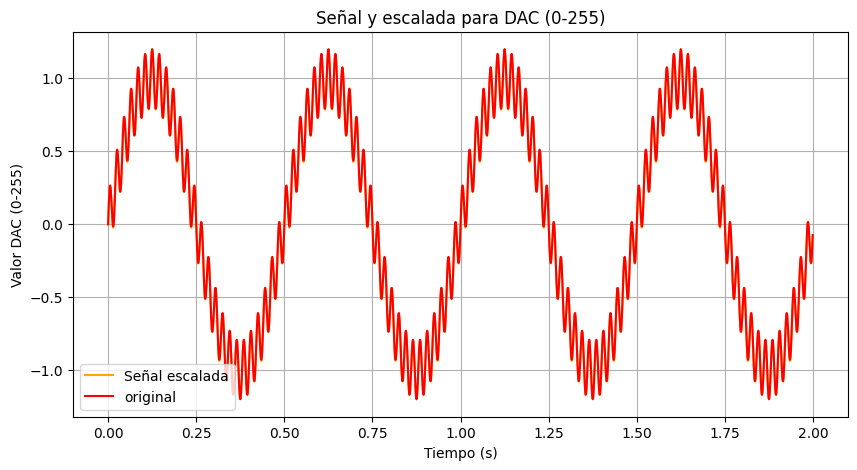

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Señal y escalada para DAC (0-255)")
plt.plot(t,(y_dac/scale_factor)+min_y, c='orange', label = "Señal escalada")
plt.plot(t,y, label="original",c="r")
plt.xlabel("Tiempo (s)")
plt.ylabel("Valor DAC (0-255)")
plt.legend()
plt.grid()
plt.show()

## FFT

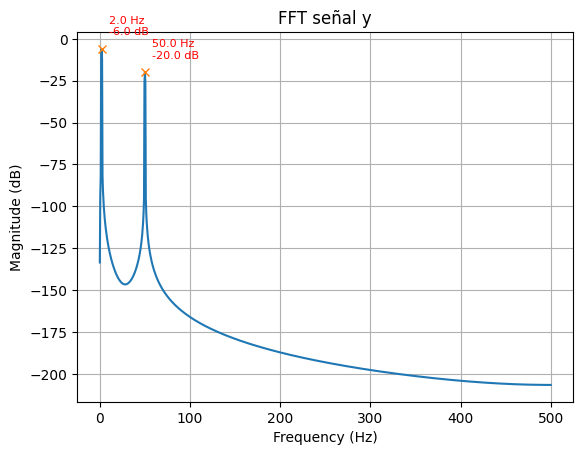

In [ ]:
from scipy.signal import find_peaks


spec, freqs, _ = plt.magnitude_spectrum(y, Fs=fs, scale='dB')
plt.title("FFT señal y")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
#plt.xlim(0,100)
plt.grid()

peaks, _ = find_peaks(spec, height=0)
plt.plot(freqs[peaks], 20*np.log10(spec[peaks]), "x")

for p in peaks:
    plt.annotate(f"{freqs[p]:.1f} Hz\n{ 20*np.log10(spec[p]):.1f} dB",
                 (freqs[p],  20*np.log10(spec[p])),
                 textcoords="offset points",
                 xytext=(5, 10),
                 ha='left',
                 fontsize=8,
                 color='red')

# for p in peaks:
#     plt.axvline(freqs[p], color='red', linestyle='--')

# Low pass filter

$$H(s) = \frac{w_{0}}{s+w_{0}}$$

- $w_{0}:$ cutoff frequency in radians/second

- $w_{0}=2\pi.fc$

fc = 5 hz

$$H(s) = \frac{2\pi.5}{s+2\pi.5}$$

In [ ]:
!pip install control

Sistema definido: H(s) = 31.42 / (s + 31.42)


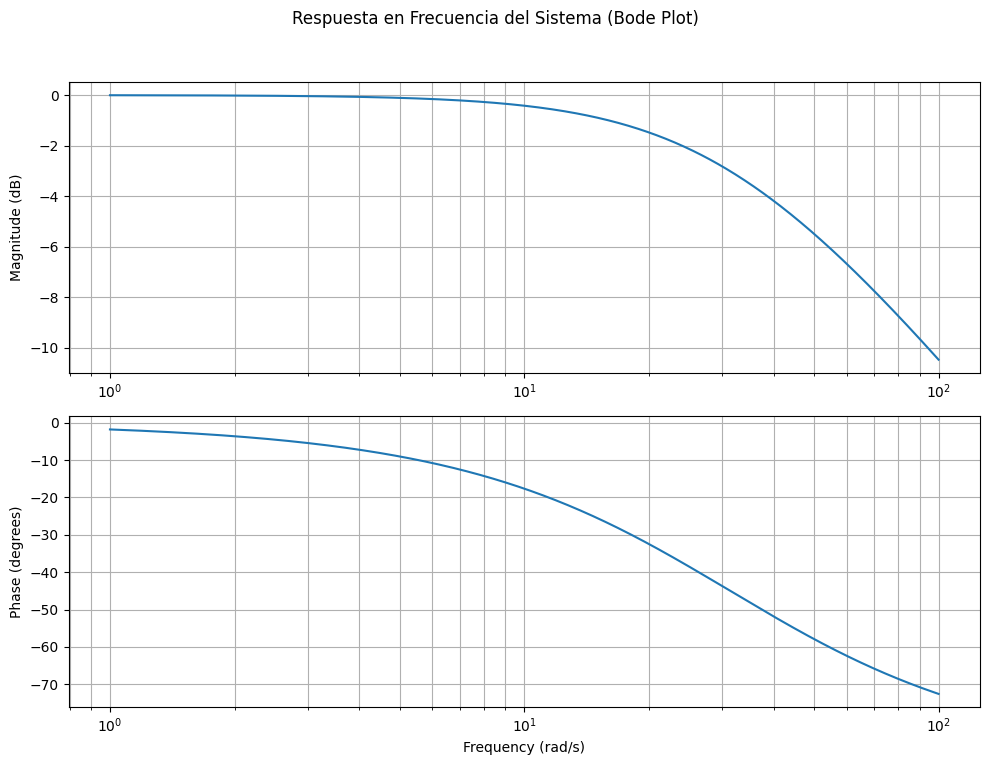

In [ ]:
import control as ctrl

fc = 5  # Cutoff frequency in Hz
w0 = 2 * np.pi * fc  # Cutoff frequency in rad/s

# Define the transfer function H(s) = w0 / (s + w0)
num = [w0]
den = [1, w0]
system = ctrl.TransferFunction(num, den)

print(f"Sistema definido: H(s) = {w0:.2f} / (s + {w0:.2f})")

# Get frequency response data using frequency_response() as recommended
mag, phase, omega = ctrl.frequency_response(system)

# Plotting Bode Diagram (Magnitude and Phase)
plt.figure(figsize=(10, 8))

# Magnitude plot
plt.subplot(2, 1, 1)
plt.semilogx(omega, 20 * np.log10(mag))
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", ls="-")

# Phase plot
plt.subplot(2, 1, 2)
plt.semilogx(omega, np.degrees(phase))
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True, which="both", ls="-")

plt.suptitle('Respuesta en Frecuencia del Sistema (Bode Plot)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

## usando scipy

In [ ]:
fc=10
w0 = 2*np.pi*fc

num = w0
den = [1, w0]

lowpass = signal.TransferFunction(num, den)
lowpass

TransferFunctionContinuous(
array([62.83185307]),
array([ 1.        , 62.83185307]),
dt: None
)

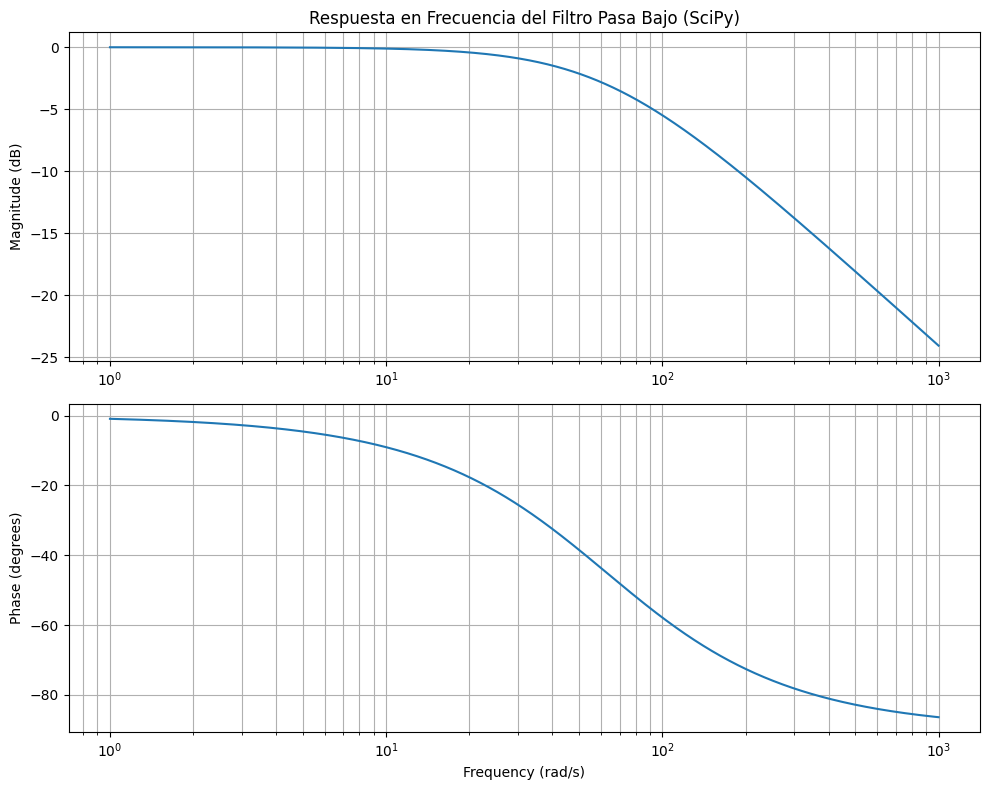

In [ ]:
# @title BODE
#import matplotlib.pyplot as plt
#from scipy import signal
#import numpy as np

w, h = signal.freqresp(lowpass)

plt.figure(figsize=(10, 8))

# Magnitude plot
plt.subplot(2, 1, 1)
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.title('Respuesta en Frecuencia del Filtro Pasa Bajo (SciPy)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", ls="-")

# Phase plot
plt.subplot(2, 1, 2)
plt.semilogx(w, np.degrees(np.angle(h)))
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

In [ ]:
signal.bilinear(num,den,fs=fs)

(array([0.03045903, 0.03045903]), array([ 1.        , -0.93908194]))

In [ ]:
# discrete transfer function

dt = 1.0/1e3
#discretelowpass = lowpass.to_discrete(dt, method='gbt', alpha=0.5)
#discretelowpass = lowpass.to_discrete(dt, method='bilinear')
discretelowpass = lowpass.to_discrete(dt, method="zoh")

discretelowpass

/usr/local/lib/python3.12/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


TransferFunctionDiscrete(
array([0.06089863]),
array([ 1.        , -0.93910137]),
dt: 0.001
)

In [ ]:
#difference equation coefficients

b = discretelowpass.num
a = -discretelowpass.den

print(f"b = {b}")
print(f"a = {a[1:]}")

b = [0.06089863]
a = [0.93910137]


In [ ]:
a

array([-1.        ,  0.93910137])

In [ ]:
b

array([0.06089863])

$$ y[n]=\alpha.y[n-1]+(1-\alpha).x[n]$$

In [ ]:
alpha=a[1]
print("alpha: ",float(alpha))

alpha:  0.9391013674242926


## Filtro iir

In [ ]:
fs = 1000       # Hz
fc = 20         # Hz
order = 4

b, a = signal.butter(order, fc/(fs/2), btype='low')

b,a

(array([1.32937289e-05, 5.31749156e-05, 7.97623734e-05, 5.31749156e-05,
        1.32937289e-05]),
 array([ 1.        , -3.67172909,  5.06799839, -3.11596693,  0.71991033]))